<a href="https://colab.research.google.com/github/JensenJones/CSS2/blob/DataPreprocessing/CSS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [109]:
import pandas as pd

# The previous error indicated that the file was not found at this path.
# Please verify the exact path to your CSV file in Google Drive.
# Ensure the file exists and is accessible at this location.
file_path = '/content/drive/MyDrive/UTS/sports_betting_predictive_analysis.csv'

df = pd.read_csv(file_path)
df.head()

,Match_ID,Date,Sport,Home_Team,Away_Team,Home_Team_Odds,Away_Team_Odds,Draw_Odds,Predicted_Winner,Actual_Winner
0,M00001,2024-01-24,Basketball,Gonzalezmouth Tigers,Hernandezfurt Lions,3.62,3.99,NaN,Hernandezfurt Lions,Hernandezfurt Lions
1,M00002,2025-05-03,Basketball,Rothstad Wolves,North Manuel Eagles,1.84,NaN,NaN,Rothstad Wolves,Rothstad Wolves
2,M00003,2025-04-10,Baseball,Aliciaport Lions,West Gabrielton Lions,3.93,3.29,NaN,Aliciaport Lions,Aliciaport Lions
3,M00004,2024-08-02,Tennis,Lake Samantha Eagles,Simonshire Lions,3.70,3.61,NaN,Simonshire Lions,Lake Samantha Eagles
4,M00005,2024-10-05,Tennis,Brendanport Eagles,Williamsfurt Bears,2.26,2.52,NaN,Williamsfurt Bears,Brendanport Eagles


In [110]:
# Fill all NaN values in the DataFrame with 0
df.fillna(0, inplace=True)

print("DataFrame after filling NaN values with 0:")
display(df.head())

DataFrame after filling NaN values with 0:


,Match_ID,Date,Sport,Home_Team,Away_Team,Home_Team_Odds,Away_Team_Odds,Draw_Odds,Predicted_Winner,Actual_Winner
0,M00001,2024-01-24,Basketball,Gonzalezmouth Tigers,Hernandezfurt Lions,3.62,3.99,0.0,Hernandezfurt Lions,Hernandezfurt Lions
1,M00002,2025-05-03,Basketball,Rothstad Wolves,North Manuel Eagles,1.84,0.00,0.0,Rothstad Wolves,Rothstad Wolves
2,M00003,2025-04-10,Baseball,Aliciaport Lions,West Gabrielton Lions,3.93,3.29,0.0,Aliciaport Lions,Aliciaport Lions
3,M00004,2024-08-02,Tennis,Lake Samantha Eagles,Simonshire Lions,3.70,3.61,0.0,Simonshire Lions,Lake Samantha Eagles
4,M00005,2024-10-05,Tennis,Brendanport Eagles,Williamsfurt Bears,2.26,2.52,0.0,Williamsfurt Bears,Brendanport Eagles


In [111]:
def encode_categorical_columns(df):
    """
    Encodes categorical columns in the DataFrame using LabelEncoder.

    Args:
        df (pd.DataFrame): DataFrame containing betting data with categorical columns to encode.

    Returns:
        pd.DataFrame: DataFrame with encoded categorical columns.
    """
    # Initialize LabelEncoder
    label_encoder = LabelEncoder()

    # Fit the LabelEncoder on all unique team names
    all_teams = pd.concat([df['Home_Team'], df['Away_Team'], df['Predicted_Winner'], df['Actual_Winner']]).unique()
    label_encoder.fit(all_teams)

    # Encode the relevant categorical columns
    df['Home_Team'] = label_encoder.transform(df['Home_Team'])
    df['Away_Team'] = label_encoder.transform(df['Away_Team'])
    df['Predicted_Winner'] = label_encoder.transform(df['Predicted_Winner'])
    df['Actual_Winner'] = label_encoder.transform(df['Actual_Winner'])

    # Optionally, encode the 'Sport' feature if it exists
    if 'Sport' in df.columns:
        df['Sport'] = label_encoder.fit_transform(df['Sport'])

    return df


In [112]:
import numpy as np

In [127]:
def calculate_arbitrage(row):
    home_odds = row['Home_Team_Odds']
    away_odds = row['Away_Team_Odds']
    draw_odds = row['Draw_Odds']

    # If any essential odds (home or away) are 0, it means the bet is invalid or not offered
    # and we cannot compute arbitrage for it.
    if home_odds == 0 or away_odds == 0:
        return 0

    # Calculate implied probabilities, handling draw_odds being 0 separately
    prob_home = 1 / home_odds
    prob_away = 1 / away_odds

    if draw_odds == 0:
        # If draw_odds is 0, it means no draw option is available for this match.
        # So, the total probability is just for home and away.
        total_prob = prob_home + prob_away
    else:
        prob_draw = 1 / draw_odds
        total_prob = prob_home + prob_away + prob_draw

    # Return 1 if there is an arbitrage opportunity (total implied probability < 1), otherwise return 0
    return 1 if total_prob < 1 else 0

In [114]:
def find_arbitrage_opportunities(df):
    """
    Process entire dataset to find arbitrage opportunities.

    Returns a DataFrame with original data and a binary 'arbitrage_exists' column.
    """
    # Apply arbitrage calculation to each row
    df['arbitrage_exists'] = df.apply(calculate_arbitrage, axis=1)

    # Generate a DataFrame containing data on arbitrage opportunities
    return df

In [115]:
def process_your_dataset(df):
    """
    Process the provided DataFrame for betting odds.

    Args:
        df (pd.DataFrame): DataFrame containing betting data.

    Returns:
        pd.DataFrame: Processed DataFrame with arbitrage opportunities.
    """
    # Assuming calculate_arbitrage is defined, calculate arbitrage opportunities
    df['arbitrage_exists'] = df.apply(calculate_arbitrage, axis=1)  # Define calculate_arbitrage separately
    arbitrage_count = df['arbitrage_exists'].sum()
    print(f'Total matches analyzed: {len(df)}')
    print(f'Arbitrage opportunities found: {arbitrage_count}')
    return df


In [116]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [128]:
# Load the dataset into a DataFrame
file_path = '/content/drive/MyDrive/UTS/sports_betting_predictive_analysis.csv'
df = pd.read_csv(file_path)

# Fill all NaN values in the DataFrame with 0 before encoding and processing
df.fillna(0, inplace=True)

# Encode categorical columns
df_encoded = encode_categorical_columns(df)

# Verify the encoding
print(df_encoded.head())
print(df_encoded[['Home_Team', 'Away_Team', 'Predicted_Winner', 'Actual_Winner', 'Sport']].dtypes)

# Process the encoded DataFrame
arb_opportunities = process_your_dataset(df_encoded)

  Match_ID        Date  Sport  Home_Team  Away_Team  Home_Team_Odds  \
0   M00001  2024-01-24      1        641        694            3.62   
1   M00002  2025-05-03      1       2042       1681            1.84   
2   M00003  2025-04-10      0         18       2515            3.93   
3   M00004  2024-08-02      4       1107       2102            3.70   
4   M00005  2024-10-05      4        134       2642            2.26   

   Away_Team_Odds  Draw_Odds  Predicted_Winner  Actual_Winner  
0            3.99        0.0               694            694  
1            0.00        0.0              2042           2042  
2            3.29        0.0                18             18  
3            3.61        0.0              2102           1107  
4            2.52        0.0              2642            134  
Home_Team           int64
Away_Team           int64
Predicted_Winner    int64
Actual_Winner       int64
Sport               int64
dtype: object
Total matches analyzed: 1369
Arbitrage opport

In [118]:
if arb_opportunities is not None:
    # Prepare features and target variable
    X = arb_opportunities[['Home_Team', 'Away_Team', 'Sport', 'Home_Team_Odds', 'Away_Team_Odds', 'Draw_Odds']]
    y = arb_opportunities['arbitrage_exists']  # Target is now binary

    # Split the data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and fit the XGBoost model
    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {accuracy:.2f}')
    print(classification_report(y_test, y_pred))
else:
    print("Could not retrieve arbitrage opportunities. Please check for prior errors.")

Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       251
           1       0.95      0.87      0.91        23

    accuracy                           0.99       274
   macro avg       0.97      0.93      0.95       274
weighted avg       0.99      0.99      0.99       274



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:29:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [119]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers


In [120]:
# Confirm the new dataframe structure
print("Columns after finding arbitrage opportunities:", df_encoded.columns)
print("First few rows of the DataFrame with arbitrage opportunities:")
print(df_encoded.head())

Columns after finding arbitrage opportunities: Index(['Match_ID', 'Date', 'Sport', 'Home_Team', 'Away_Team', 'Home_Team_Odds',
       'Away_Team_Odds', 'Draw_Odds', 'Predicted_Winner', 'Actual_Winner',
       'arbitrage_exists'],
      dtype='object')
First few rows of the DataFrame with arbitrage opportunities:
  Match_ID        Date  Sport  Home_Team  Away_Team  Home_Team_Odds  \
0   M00001  2024-01-24      1        641        694            3.62   
1   M00002  2025-05-03      1       2042       1681            1.84   
2   M00003  2025-04-10      0         18       2515            3.93   
3   M00004  2024-08-02      4       1107       2102            3.70   
4   M00005  2024-10-05      4        134       2642            2.26   

   Away_Team_Odds  Draw_Odds  Predicted_Winner  Actual_Winner  \
0            3.99        NaN               694            694   
1             NaN        NaN              2042           2042   
2            3.29        NaN                18             18   

In [129]:
X = df_encoded[['Home_Team', 'Away_Team', 'Sport', 'Home_Team_Odds', 'Away_Team_Odds', 'Draw_Odds']]
y = df_encoded['arbitrage_exists']

In [130]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [131]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check for NaN or infinite values
if np.any(np.isnan(X_train_scaled)) or np.any(np.isinf(X_train_scaled)):
    print("Input data contains NaN or infinite values.")
else:
    print("No NaN or infinite values found in X_train_scaled.")

if np.any(np.isnan(X_test_scaled)) or np.any(np.isinf(X_test_scaled)):
    print("Test data contains NaN or infinite values.")
else:
    print("No NaN or infinite values found in X_test_scaled.")

No NaN or infinite values found in X_train_scaled.
No NaN or infinite values found in X_test_scaled.


In [132]:
from tensorflow.keras.optimizers import Adam

# Build the model
model = keras.Sequential()
model.add(layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))  # Input layer
model.add(layers.Dense(64, activation='relu'))  # Hidden layer
model.add(layers.Dense(32, activation='relu'))  # Hidden layer
model.add(layers.Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Compile the model
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [133]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4201 - loss: 0.7003 - val_accuracy: 0.5799 - val_loss: 0.6875
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6689 - loss: 0.6741 - val_accuracy: 0.7671 - val_loss: 0.6643
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7922 - loss: 0.6501 - val_accuracy: 0.8037 - val_loss: 0.6409
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8288 - loss: 0.6244 - val_accuracy: 0.8219 - val_loss: 0.6153
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8482 - loss: 0.5951 - val_accuracy: 0.8219 - val_loss: 0.5873
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8573 - loss: 0.5632 - val_accuracy: 0.8539 - val_loss: 0.5569
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8630 - loss: 0.5288 - val_accuracy: 0.8539 - val_loss: 0.5233
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8710 - loss: 0.4927 - val_accuracy: 0.8493 - val_loss

In [134]:
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,797 (132.02 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,532 (88.02 KB)

None


In [135]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f'Test Accuracy: {test_accuracy:.2f}')

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9416 - loss: 0.1714 
Test Accuracy: 0.94


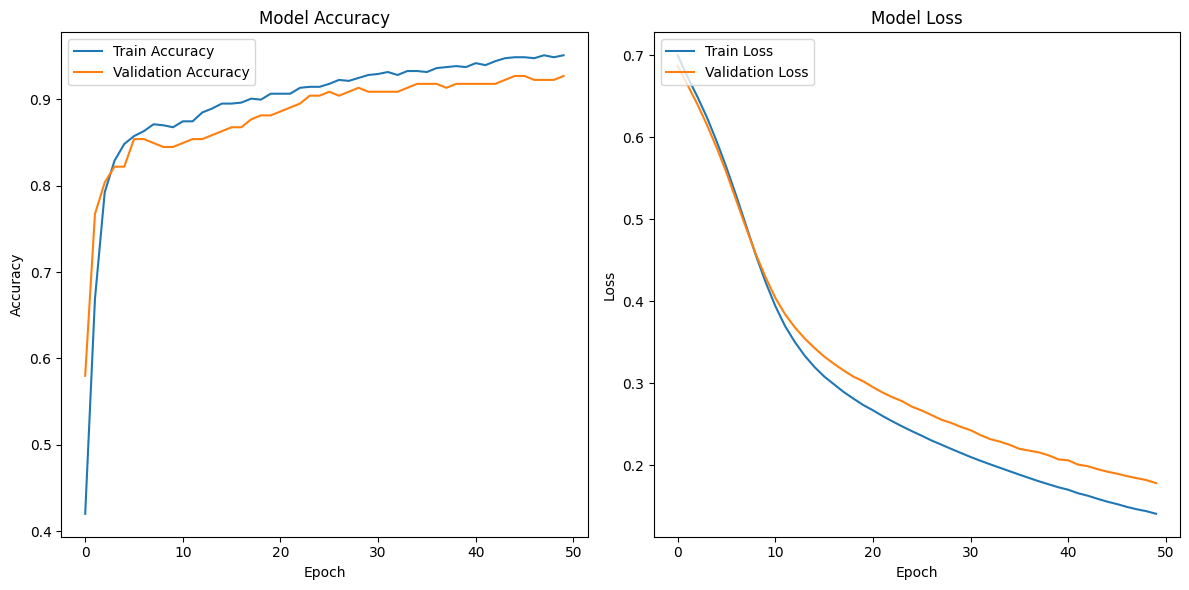

In [136]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)  # Create subplot for accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)  # Create subplot for loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()  # Adjust subplots to fit into the figure area.
plt.show()
